# Kunci Jawaban - Linear Regression

- **Dataset:** [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)
- **Target:** `quality`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [ ]:
%pip install ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan line plot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE, count plot, dan boxplot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Wine Quality menggunakan ID dataset dari UCI.

In [5]:
wine_quality = fetch_ucirepo(id=186)

### Ambil fitur dari dataset

Simpan fitur dataset ke variabel `X_raw`.

In [6]:
X_raw = wine_quality.data.features.copy()

### Ambil target dari dataset

Simpan target dataset ke variabel `y_raw`.

In [7]:
y_raw = wine_quality.data.targets.copy()

### Tentukan kolom target

Simpan nama kolom target ke variabel `TARGET_COL` agar mudah dipakai ulang di bagian berikutnya.

In [8]:
TARGET_COL = "quality"

### Gabungkan fitur dan target

Gabungkan fitur dan target menjadi satu DataFrame bernama `df` agar mudah dicek di tahap EDA.

In [9]:
df = pd.concat([X_raw, y_raw], axis=1)

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom dataset.

In [10]:
df.shape

(6497, 12)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki **6497 baris** dan **12 kolom**.

> Berapa jumlah fitur dan targetnya?

Jawaban: Dataset memiliki **11 fitur** dan **1 target**, yaitu `quality`.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat bentuk data.

In [11]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5
1,7.800,0.880,0.000,2.600,0.098,25.000,67.000,0.997,3.200,0.680,9.800,5
2,7.800,0.760,0.040,2.300,0.092,15.000,54.000,0.997,3.260,0.650,9.800,5
3,11.200,0.280,0.560,1.900,0.075,17.000,60.000,0.998,3.160,0.580,9.800,6
4,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Ya, semua kolom berisi angka.

> Apakah dataset membutuhkan encoding kategori sebelum modeling?

Jawaban: Tidak, dataset tidak membutuhkan encoding kategori karena seluruh kolom berupa data numerik.

## 3 - Data Understanding

### Tampilkan informasi dataset

Gunakan `info()` untuk melihat tipe data dan jumlah data non-null.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


> Berdasarkan output `info()`, apa tipe data setiap kolom?

Jawaban: Dataset memiliki **11 kolom float64** dan **1 kolom int64**.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak, semua kolom memiliki jumlah non-null yang sama dengan jumlah baris dataset, yaitu **6497 non-null**.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [13]:
df.isna().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value. Semua kolom memiliki missing value **0**.

> Apakah data perlu diisi menggunakan mean, median, atau metode imputasi lain?

Jawaban: Tidak perlu, karena dataset tidak memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris yang duplikat penuh.

In [14]:
df.duplicated().sum()

np.int64(1179)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Terdapat **1179 baris duplikat penuh**.

> Apa keputusan cleaning yang perlu dilakukan?

Jawaban: Baris duplikat perlu dihapus agar data tidak menghitung sampel yang sama lebih dari satu kali.

### Tampilkan statistik deskriptif

Gunakan `describe()` untuk melihat ringkasan nilai numerik pada dataset.

In [15]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000


> Berdasarkan statistik deskriptif, bagaimana perbedaan skala antar fitur?

Jawaban: Skala antar fitur berbeda. Contohnya, sulfur dioxide dapat bernilai puluhan hingga ratusan, sedangkan density dan pH berada pada rentang yang lebih kecil.

> Mengapa scaling diperlukan sebelum model dilatih?

Jawaban: Scaling diperlukan agar perbedaan satuan dan skala antar fitur tidak terlalu memengaruhi proses modeling.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh dari dataset.

In [16]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index agar nomor baris kembali rapi setelah duplikat dihapus.

In [17]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah duplikat dihapus.

In [18]:
df_clean.shape

(5318, 12)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Setelah duplikat dihapus, dataset memiliki **5318 baris** dan **12 kolom**.

> Berapa jumlah baris yang berkurang dari dataset awal?

Jawaban: Jumlah baris berkurang sebanyak **1179 baris**, dari 6497 menjadi 5318 baris.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat yang tersisa.

In [19]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak, jumlah duplikat setelah cleaning adalah **0**.

> Jelaskan kondisi dataset setelah duplikat dihapus.

Jawaban: Dataset sudah lebih bersih karena tidak ada baris duplikat penuh yang tersisa.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Lihat ringkasan statistik kolom target.

In [20]:
df_clean[TARGET_COL].describe()

count   5318.000
mean       5.796
std        0.880
min        3.000
25%        5.000
50%        6.000
75%        6.000
max        9.000
Name: quality, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Target memiliki mean sekitar **5.80**, nilai minimum **3**, dan nilai maksimum **9**.

> Apa yang bisa disimpulkan dari rentang nilai target tersebut?

Jawaban: Nilai quality berada pada skor terbatas, sehingga target bersifat numerik diskret.

### Buat count plot target

Gunakan count plot karena target `quality` berupa skor diskret.

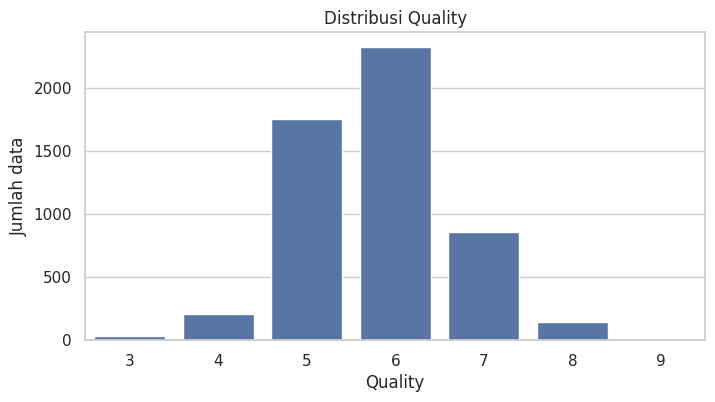

In [21]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x=TARGET_COL)
plt.title("Distribusi Quality")
plt.xlabel("Quality")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan count plot, skor quality mana yang paling banyak muncul?

Jawaban: Skor quality yang paling banyak muncul berada di sekitar **5** dan **6**.

> Mengapa count plot lebih tepat daripada histogram biasa untuk target ini?

Jawaban: Count plot lebih tepat karena `quality` berupa skor diskret, bukan nilai kontinu.

### Hitung korelasi fitur dengan target

Hitung korelasi setiap fitur terhadap target.

In [22]:
corr_with_target = df_clean.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
corr_with_target

alcohol                 0.469
citric_acid             0.098
free_sulfur_dioxide     0.054
sulphates               0.042
pH                      0.040
total_sulfur_dioxide   -0.050
residual_sugar         -0.057
fixed_acidity          -0.080
chlorides              -0.202
volatile_acidity       -0.265
density                -0.326
Name: quality, dtype: float64

> Berdasarkan output korelasi, fitur apa saja yang memiliki korelasi positif paling terlihat terhadap target?

Jawaban: `alcohol` memiliki korelasi positif paling terlihat terhadap target, diikuti `citric_acid` dan `free_sulfur_dioxide` dengan korelasi lebih kecil.

> Fitur apa yang memiliki korelasi negatif terhadap target?

Jawaban: `density`, `volatile_acidity`, dan `chlorides` memiliki korelasi negatif terhadap target.

### Buat bar plot korelasi

Gunakan bar plot untuk melihat korelasi fitur dengan target secara visual.

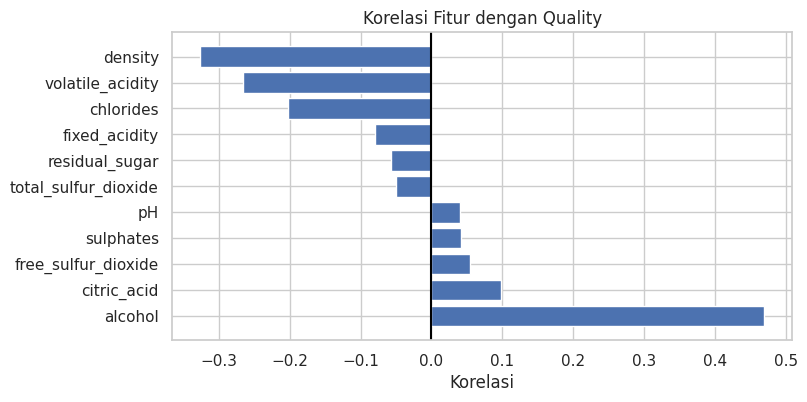

In [23]:
plt.figure(figsize=(8, 4))
plt.barh(corr_with_target.index, corr_with_target.values)
plt.axvline(0, color="black")
plt.title("Korelasi Fitur dengan Quality")
plt.xlabel("Korelasi")
plt.show()

> Berdasarkan bar plot, fitur mana yang berada pada sisi korelasi positif dan sisi korelasi negatif?

Jawaban: Sisi positif berisi fitur seperti `alcohol`, `citric_acid`, dan `free_sulfur_dioxide`. Sisi negatif berisi `density`, `volatile_acidity`, `chlorides`, dan beberapa fitur lain.

> Apa arti arah korelasi tersebut terhadap target?

Jawaban: Korelasi positif berarti nilai fitur cenderung naik bersama quality, sedangkan korelasi negatif berarti nilai fitur cenderung naik ketika quality menurun.

### Buat boxplot Alcohol berdasarkan Quality

Gunakan boxplot karena target `quality` berbentuk skor kelompok.

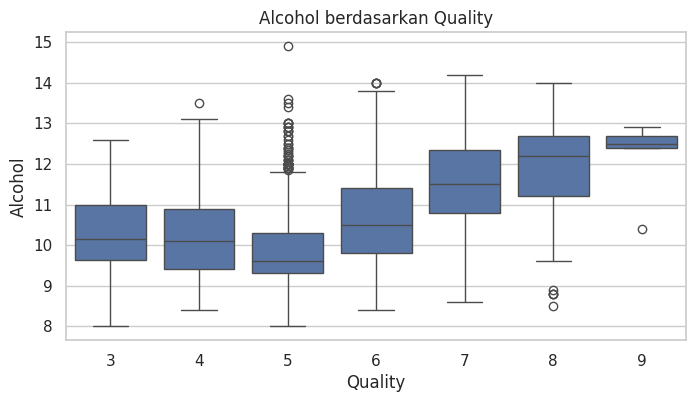

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x=TARGET_COL, y="alcohol")
plt.title("Alcohol berdasarkan Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

> Berdasarkan boxplot, bagaimana pola `alcohol` pada skor quality yang berbeda?

Jawaban: Wine dengan skor quality lebih tinggi cenderung memiliki nilai `alcohol` yang lebih tinggi.

> Mengapa boxplot lebih tepat daripada scatter plot untuk bagian ini?

Jawaban: Boxplot lebih tepat karena `quality` berbentuk skor diskret, sehingga lebih mudah dibandingkan per kelompok skor.

### Buat boxplot Volatile Acidity berdasarkan Quality

Gunakan boxplot untuk membandingkan `volatile_acidity` pada setiap skor quality.

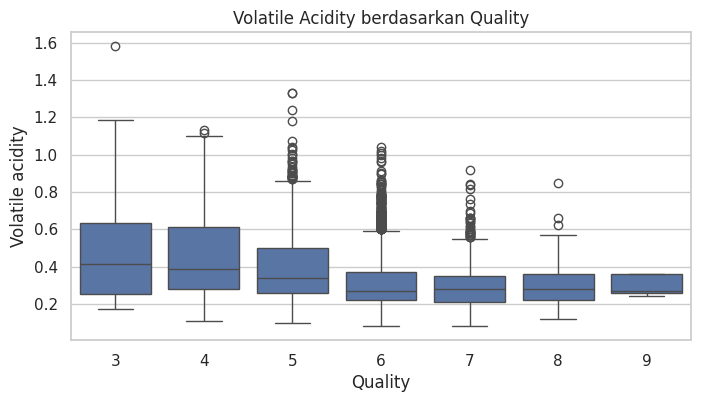

In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x=TARGET_COL, y="volatile_acidity")
plt.title("Volatile Acidity berdasarkan Quality")
plt.xlabel("Quality")
plt.ylabel("Volatile acidity")
plt.show()

> Berdasarkan boxplot, bagaimana pola `volatile_acidity` pada skor quality yang berbeda?

Jawaban: Wine dengan skor quality lebih tinggi cenderung memiliki `volatile_acidity` yang lebih rendah.

> Apa arti pola tersebut terhadap target?

Jawaban: Pola tersebut menunjukkan hubungan negatif antara `volatile_acidity` dan quality.

## 6 - Feature dan Target

### Pisahkan fitur

Simpan semua kolom selain target ke variabel `X`.

In [26]:
X = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke variabel `y`.

In [27]:
y = df_clean[TARGET_COL]

### Tampilkan ukuran fitur

Cek ukuran `X` setelah fitur dipisahkan.

In [28]:
X.shape

(5318, 11)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki **5318 baris** dan **11 fitur**.

### Tampilkan ukuran target

Cek ukuran `y` setelah target dipisahkan.

In [29]:
y.shape

(5318,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki **5318 nilai target**.

> Apakah jumlah baris `X` dan `y` sudah sama?

Jawaban: Ya, jumlah baris `X` dan `y` sudah sama, yaitu **5318**.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [30]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji yang digunakan adalah **20%**, sedangkan data latih adalah **80%** dari seluruh dataset.

### Bagi data train dan test

Bagi data menjadi data train dan test.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Cek jumlah data dan fitur pada `X_train`.

In [32]:
X_train.shape

(4254, 11)

### Tampilkan ukuran X_test

Cek jumlah data dan fitur pada `X_test`.

In [33]:
X_test.shape

(1064, 11)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki **4254 baris**, sedangkan data test memiliki **1064 baris**.

> Apakah jumlah fitur pada train dan test tetap sama?

Jawaban: Ya, jumlah fitur pada train dan test tetap sama, yaitu **11 fitur**.

## 8 - Feature Scaling

### Buat object scaler

Gunakan `StandardScaler` untuk menstandarkan fitur.

In [34]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler hanya pada data train, lalu transform data train.

In [35]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Transform data test menggunakan scaler yang sudah di-fit pada data train.

In [36]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [37]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [38]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan untuk prediksi?

Jawaban: Output `LinearRegression()` menunjukkan bahwa object model sudah berhasil dilatih dan siap digunakan untuk prediksi.

### Tampilkan intercept model

Tampilkan nilai intercept dari model.

In [39]:
model.intercept_

np.float64(5.787729196050767)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar **5.79**.

> Apa makna intercept setelah seluruh fitur di-scale?

Jawaban: Intercept adalah nilai dasar prediksi ketika seluruh fitur berada pada titik nol setelah scaling.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel sederhana.

In [40]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_table.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
10,alcohol,0.311
3,residual_sugar,0.169
9,sulphates,0.125
5,free_sulfur_dioxide,0.124
8,pH,0.086
0,fixed_acidity,0.076
2,citric_acid,0.022
4,chlorides,-0.025
6,total_sulfur_dioxide,-0.151
7,density,-0.173


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar dan koefisien negatif terbesar?

Jawaban: Koefisien positif terbesar adalah `alcohol` sekitar **0.31**, sedangkan koefisien negatif terbesar adalah `volatile_acidity` sekitar **-0.19**.

> Apa arti tanda positif dan negatif pada koefisien?

Jawaban: Koefisien positif berarti fitur cenderung menaikkan prediksi, sedangkan koefisien negatif berarti fitur cenderung menurunkan prediksi.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk memprediksi data train.

In [41]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk memprediksi data test.

In [42]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama dari data test.

In [43]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": y_test_pred[:5]
})
prediction_preview

,Actual,Predicted
0,6,6.464
1,6,6.096
2,6,6.170
3,5,6.098
4,6,6.424


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dan paling jauh dari nilai aktual?

Jawaban: Prediksi paling dekat terlihat pada baris ke-2, dengan aktual **6** dan prediksi **6.10**. Prediksi paling jauh terlihat pada baris ke-4, dengan aktual **5** dan prediksi **6.10**.

> Apa yang bisa disimpulkan dari selisih aktual dan prediksi?

Jawaban: Prediksi berada cukup dekat untuk beberapa data, tetapi model masih bisa meleset sekitar satu skor quality.

### Hitung MAE train

Hitung rata-rata error absolut pada data train.

In [44]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

0.5671430986716862

### Hitung MAE test

Hitung rata-rata error absolut pada data test.

In [45]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

0.5520365984973948

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar **0.55**.

> Apa arti rata-rata error absolut tersebut?

Jawaban: Artinya, rata-rata prediksi model meleset sekitar **0.55 skor quality** dari nilai aktual.

### Hitung RMSE train

Hitung RMSE pada data train.

In [46]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(0.7367129642172056)

### Hitung RMSE test

Hitung RMSE pada data test.

In [47]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(0.7138987584873353)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar **0.71**.

> Mengapa nilai RMSE dapat lebih besar daripada MAE?

Jawaban: RMSE dapat lebih besar daripada MAE karena RMSE memberi penalti lebih besar pada error yang besar.

### Hitung R2 train

Hitung R2 Score pada data train.

In [48]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.30358402153752717

### Hitung R2 test

Hitung R2 Score pada data test.

In [49]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.3206183782186054

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar **0.32**.

> Berapa persen variasi target pada data test yang dapat dijelaskan oleh model?

Jawaban: Model dapat menjelaskan sekitar **32%** variasi quality pada data test.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 ke dalam satu tabel ringkas.

In [50]:
evaluation_table = pd.DataFrame({
    "Subset": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
})
evaluation_table

,Subset,MAE,RMSE,R2
0,Train,0.567,0.737,0.304
1,Test,0.552,0.714,0.321


> Berdasarkan tabel evaluasi, bandingkan MAE, RMSE, dan R2 pada data train dan data test.

Jawaban: MAE test lebih kecil daripada MAE train, RMSE test lebih kecil daripada RMSE train, dan R2 test lebih besar daripada R2 train.

> Berapa persen perbedaannya, dan apa makna perbandingan tersebut?

Jawaban: MAE test sekitar **2.66%** lebih kecil, RMSE test sekitar **3.10%** lebih kecil, dan R2 test sekitar **5.61%** lebih besar dibanding train. Performa train dan test cukup mirip, tetapi R2 masih rendah.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk melihat kedekatan nilai aktual dan prediksi pada data test.

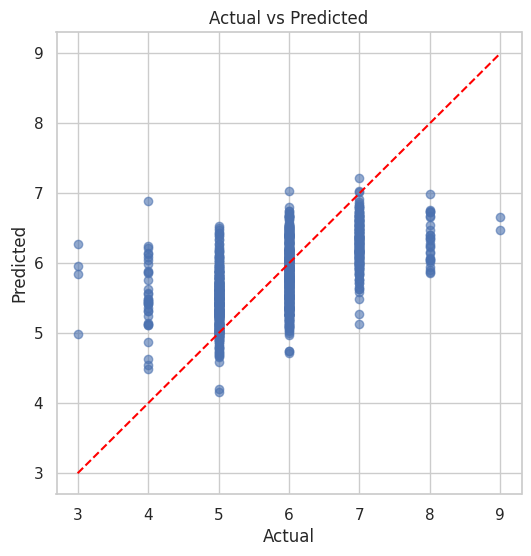

In [51]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 11 - Kesimpulan

Dataset Wine Quality digunakan untuk memprediksi `quality` berdasarkan fitur kimia wine. Data tidak memiliki missing value dan memiliki **1179** baris duplikat penuh. Setelah cleaning, dataset memiliki **5318** baris dan **12** kolom.

Hasil EDA menunjukkan bahwa `alcohol` memiliki hubungan positif paling terlihat dengan target, sedangkan `density` dan `volatile_acidity` cenderung memiliki hubungan negatif. Data dibagi menjadi **80%** data train dan **20%** data test, lalu fitur di-scale menggunakan `StandardScaler`.

Model Linear Regression menghasilkan MAE test sekitar **0.55**, RMSE test sekitar **0.71**, dan R2 test sekitar **0.32**. Berdasarkan metrik tersebut, model mampu menjelaskan sekitar **32%** variasi target pada data test dengan rata-rata error absolut sekitar **0.55 skor quality**.